Estimating Pi with Spark on Google Colab
- toc: true 
- badges: true
- comments: true
- image: images/colab/spark-colab.png
- categories: [google-colab, spark, pyspark]

# Estimating Pi with Spark on Google Colab

This notebook will demonstrate how easily you can use Spark on Google Colab and how fun it is to estimate π!

Here's how we'll do it:

There's this method called Monte Carlo simulation and I think it's one of my favorite "discrete simulation" :) With this method, we will estimate π by throwing "stones" to a unit circle, and the bounds will be the bounding unit square of this circle. This means that, we're throwing stones into 2x2 = 4 units of area, where 1 unit is the radius of our circle - thus the "unit circle".

So, we will pick the random stones in the unit square ((0, 0) to (1,1)) and see how many fall in this unit circle. The inside to outside ratio should be π / 4, so this formula will estimate π for us.

## Install Spark On Google Colab and Mount Google Drive

Let's first install Spark on Google Colab. As of today, the latest version is 2.4.5 so we're grabbing that URL and giving it to wget.

After the installation, we'll set the environment path which enables us to run PySpark in our Colab environment.

In [0]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q !wget -q http://apache.osuosl.org/spark/spark-2.4.5/spark-2.4.5-bin-hadoop2.7.tgz
!tar xf spark-2.4.5-bin-hadoop2.7.tgz
!pip install -q findspark

In [0]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-2.4.5-bin-hadoop2.7"


Now let's test our Spark installation and check our version.

In [9]:
import findspark
findspark.init()
import pyspark as ps

spark = (ps.sql.SparkSession.builder
        .appName("colab")
        .getOrCreate()
        )

print(spark.version)

2.4.5


Now let's mount our Google Drive so that we can access it from within Google Colab here. Follow the instructions and then when it's ready, we will cd to that folder next.

In [10]:
from google.colab import drive
drive.mount('/content/gdrive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/gdrive


In [11]:
%cd /content/gdrive/My\ Drive/demo

/content/gdrive/My Drive/demo


## Time to estimate Pi!

In [43]:
%%writefile estimate-pi.py

import pyspark as ps
import random

def is_inside_circle(p):
    x, y = random.random(), random.random()
    return x*x + y*y < 1


spark = ps.sql.SparkSession.builder.appName("estimate-pi").getOrCreate()
sc = spark.sparkContext

NUM_SAMPLES = 10000000
count = sc.parallelize(range(NUM_SAMPLES)) \
             .filter(is_inside_circle).count()
pi = (4.0 * count / NUM_SAMPLES)

print(f"Pi is estimated as {pi}")
print({"pi":pi}, file=open("/content/gdrive/My Drive/demo/estimate-pi-out.txt", "w"))

Overwriting estimate-pi.py


In [44]:
!$SPARK_HOME/bin/spark-submit /content/gdrive/My\ Drive/demo/estimate-pi.py

20/05/31 19:40:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
20/05/31 19:40:29 INFO SparkContext: Running Spark version 2.4.5
20/05/31 19:40:29 INFO SparkContext: Submitted application: estimate-pi
20/05/31 19:40:29 INFO SecurityManager: Changing view acls to: root
20/05/31 19:40:29 INFO SecurityManager: Changing modify acls to: root
20/05/31 19:40:29 INFO SecurityManager: Changing view acls groups to: 
20/05/31 19:40:29 INFO SecurityManager: Changing modify acls groups to: 
20/05/31 19:40:29 INFO SecurityManager: SecurityManager: authentication disabled; ui acls disabled; users  with view permissions: Set(root); groups with view permissions: Set(); users  with modify permissions: Set(root); groups with modify permissions: Set()
20/05/31 19:40:29 INFO Utils: Successfully started service 'sparkDriver' on port 33461.
20/05/31 19

So, at the end of this flow, you should have this folder on Google Drive with these contents:

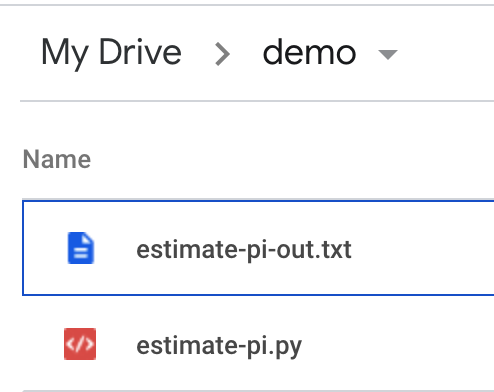

And finally, let's confirm that we see the result on our output file.

From the Spark logs above, we read that:
`Pi is estimated as 3.1417808`

Now let's confirm this by reading our out file too.


In [45]:
with open("/content/gdrive/My Drive/demo/estimate-pi-out.txt") as file:  
    print(file.read())
    


{'pi': 3.1417808}

